<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-XLA/blob/main/BaiTap_ThucHanh_XuLyAnh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#BÀI TẬP THỰC HÀNH – Xử lý ảnh miền không gian
### Thảo luận giữa kỳ · Môn Xử lý ảnh · Lớp MIT26K5 · Trường ĐH Bà Rịa – Vũng Tàu

Hai bài tập ngắn để cả lớp cùng làm, gắn với đúng nội dung nhóm vừa trình bày.

---

## Bước 0 — Chuẩn bị (chạy một lần)

Kết nối Google Drive để đọc ảnh mẫu. Colab sẽ hiện cửa sổ xin quyền — bấm **cho phép**.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import cv2, numpy as np, os
import matplotlib.pyplot as plt

# Duong dan thu muc anh tren Google Drive cua nhom
IMAGE_PATH = "/content/drive/My Drive/Colab Notebooks/xla_tl_n2_data_img"
FILES = {"sieuthi": "sieuthi_toi.jpg", "buom": "buom.jpg"}

# Ket noi Google Drive
from google.colab import drive
drive.mount('/content/drive')

def load(ten):
    """Doc anh mau tu thu muc tren Google Drive."""
    p = os.path.join(IMAGE_PATH, FILES[ten])
    img = cv2.imread(p)
    if img is None:
        raise FileNotFoundError(
            'Khong doc duoc anh: ' + p + '\n'
            '  -> Kiem tra: (1) da bam cho phep mount Drive chua?  '
            '(2) file ' + FILES[ten] + ' da nam dung thu muc '
            'My Drive/Colab Notebooks/xla_tl_n2_data_img/ chua?')
    print('  Da doc', FILES[ten], 'tu Drive')
    return img   # anh BGR

def show(cac_anh, tieu_de, xam=False):
    """Hien thi nhieu anh canh nhau. cac_anh = [(ten, anh), ...]"""
    n = len(cac_anh)
    plt.figure(figsize=(4*n, 4))
    for i, (ten, a) in enumerate(cac_anh, 1):
        plt.subplot(1, n, i); plt.title(ten); plt.axis('off')
        if xam or a.ndim == 2:
            plt.imshow(a, cmap='gray', vmin=0, vmax=255)
        else:
            plt.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
    plt.suptitle(tieu_de); plt.tight_layout(); plt.show()

print('San sang! Chay tiep cac o ben duoi.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
San sang! Chay tiep cac o ben duoi.


---
## Bài tập 1 — Cứu bức ảnh siêu thị thiếu sáng
*(Chương 2 · gắn với Hình 4.1 và Hình 5.2 trong báo cáo)*

Ảnh camera siêu thị bị **tối**. Bạn hãy:

**(a)** Kéo sáng bằng **hiệu chỉnh gamma** (kỹ thuật bảng tra LUT – mục 4.3).
**(b)** Cân bằng histogram theo **hai cách** rồi so màu: áp thẳng trên 3 kênh BGR so với áp trên kênh L của LAB (mục 4.4).

**Đoán trước khi chạy:** để kéo sáng vùng tối thì gamma nên **< 1 hay > 1**? Cân bằng ảnh màu trên **3 kênh BGR hay trên kênh L** thì giữ được màu?

  Da doc sieuthi_toi.jpg tu Drive
Do sang trung binh:  goc = 26  ->  sau gamma = 68


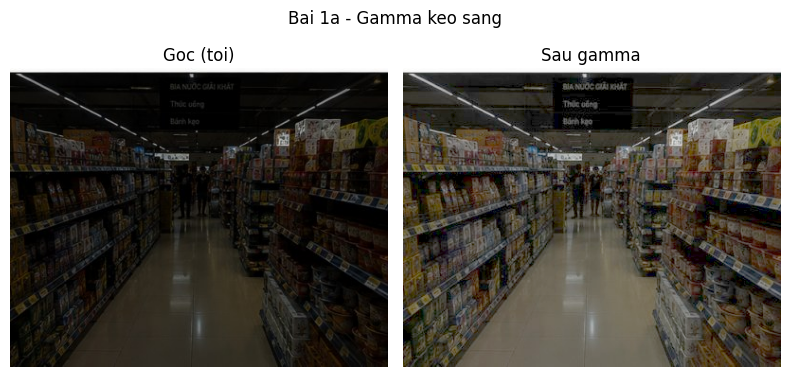

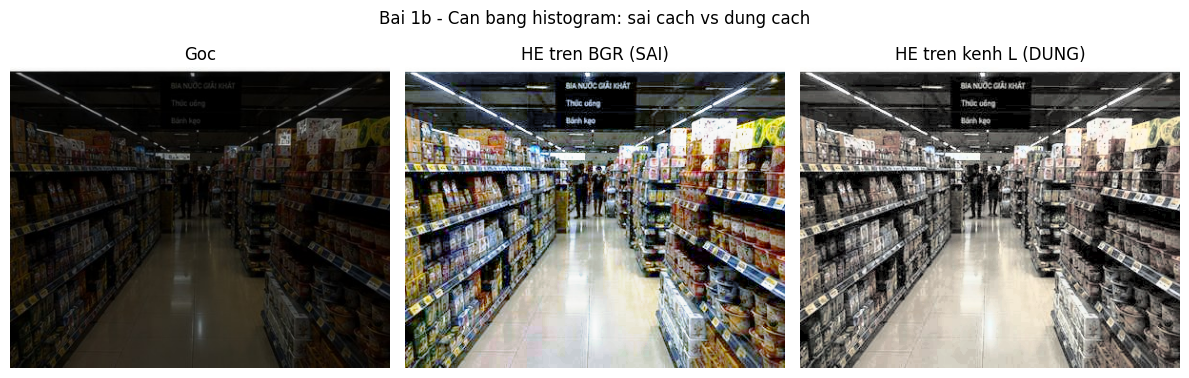

In [8]:
img = load('sieuthi')

# ---- (a) GAMMA keo sang ----
gamma = 0.5      #THU DOI so nay roi chay lai:  <1 keo sang,  >1 lam toi  (thu 0.3 / 1.0 / 2.0)
lut  = np.array([((i/255.0)**gamma)*255 for i in range(256)], np.uint8)
sang = cv2.LUT(img, lut)

# ---- (b) Can bang histogram: SAI cach (3 kenh BGR) vs DUNG cach (kenh L cua LAB) ----
he_sai  = cv2.merge([cv2.equalizeHist(c) for c in cv2.split(img)])   # sai: tung kenh BGR
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)                           # dung: chuyen sang LAB
L, A, B = cv2.split(lab)
he_dung = cv2.cvtColor(cv2.merge([cv2.equalizeHist(L), A, B]), cv2.COLOR_LAB2BGR)

print('Do sang trung binh:  goc = %.0f  ->  sau gamma = %.0f' % (img.mean(), sang.mean()))
show([('Goc (toi)', img), ('Sau gamma', sang)], 'Bai 1a - Gamma keo sang')
show([('Goc', img), ('HE tren BGR (SAI)', he_sai), ('HE tren kenh L (DUNG)', he_dung)],
     'Bai 1b - Can bang histogram: sai cach vs dung cach')

<details><summary>Xem <b>GIẢI THÍCH Bài 1</b></summary>

- **Gamma < 1** kéo sáng vùng tối (đường cong lồi lên). Với `gamma = 0.5`, độ sáng trung bình tăng khoảng **26 → 68**. Thử `gamma = 2.0` sẽ thấy ảnh tối đi.
- Cân bằng histogram trên **3 kênh BGR** làm **sai màu rõ** (hàng hóa đổi màu) vì ba kênh bị kéo lệch nhau; làm trên **kênh L của LAB** thì chỉ độ sáng đổi, màu giữ nguyên — đúng như **Hình 4.1** trong báo cáo.
</details>

---
## Bài tập 2 — Chọn đúng bộ lọc cho đúng loại nhiễu
*(Chương 3 · gắn với Bảng 2.3 / Bảng 3.2 và Hình 2.3)*

Cùng một ảnh, ta thêm **hai loại nhiễu**: nhiễu Gaussian (hạt mịn – như nhiễu cảm biến) và nhiễu muối tiêu (chấm đen trắng – nhiễu xung).

Áp cả `GaussianBlur` và `medianBlur` lên từng ảnh, rồi đo **PSNR** so với ảnh gốc sạch (PSNR càng cao càng gần ảnh gốc = lọc càng tốt).

**Đoán trước khi chạy:** bộ lọc nào sẽ thắng ở **nhiễu Gaussian**? Ở **nhiễu muối tiêu**?

  Da doc buom.jpg tu Drive
Loai nhieu           nhieu  Gaussian    Median
Nhieu Gaussian        22.5      24.2      22.5
Nhieu muoi tieu       14.9      21.6      22.6


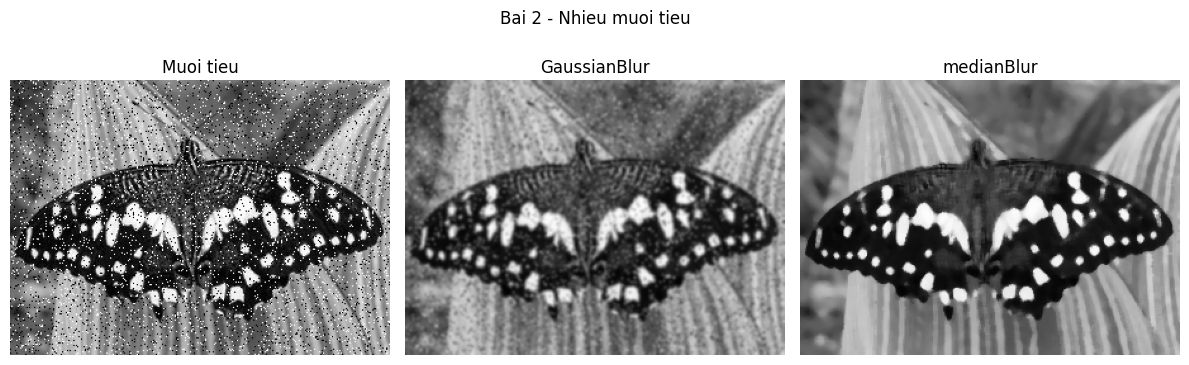

In [9]:
goc = cv2.cvtColor(load('buom'), cv2.COLOR_BGR2GRAY)   # anh goc sac net

# Tao 2 loai nhieu
rng = np.random.default_rng(0)
gaussian = np.clip(goc + rng.normal(0, 20, goc.shape), 0, 255).astype(np.uint8)
muoitieu = goc.copy(); m = rng.random(goc.shape)
muoitieu[m < 0.05] = 0; muoitieu[m > 0.95] = 255

def psnr(sach, loc):
    mse = np.mean((sach.astype(float) - loc.astype(float))**2)
    return 99 if mse == 0 else 10*np.log10(255**2/mse)

ksize = 5        # 👉 THU DOI kich thuoc cua so loc (so LE: 3, 5, 7) roi chay lai
print('%-16s %9s %9s %9s' % ('Loai nhieu','nhieu','Gaussian','Median'))
for ten, anh in [('Nhieu Gaussian', gaussian), ('Nhieu muoi tieu', muoitieu)]:
    loc_g   = cv2.GaussianBlur(anh, (ksize, ksize), 0)   # bo loc lam tron Gaussian
    loc_med = cv2.medianBlur(anh, ksize)                 # bo loc trung vi
    print('%-16s %9.1f %9.1f %9.1f' % (ten, psnr(goc,anh), psnr(goc,loc_g), psnr(goc,loc_med)))

# Xem tan mat voi anh nhieu muoi tieu
show([('Muoi tieu', muoitieu),
      ('GaussianBlur', cv2.GaussianBlur(muoitieu,(ksize,ksize),0)),
      ('medianBlur', cv2.medianBlur(muoitieu,ksize))], 'Bai 2 - Nhieu muoi tieu', xam=True)

<details><summary>Xem <b>GIẢI THÍCH Bài 2</b></summary>

**Kết quả (PSNR, dB — càng cao càng tốt), với `ksize = 5`:**

| Loại nhiễu | Gaussian | Median | Thắng |
|---|---|---|---|
| Nhiễu Gaussian | **24,2** | 22,5 | Gaussian |
| Nhiễu muối tiêu | 21,6 | **22,6** | Median |

**Bài học:** *nhìn loại nhiễu trước, đừng nhìn tên bộ lọc.* Nhiễu cảm biến (Gaussian) → dùng GaussianBlur; nhiễu xung (muối tiêu) → chỉ medianBlur mới khử sạch mà giữ được biên — đúng như **Bảng 2.3** trong báo cáo.
</details>

---
## Rút ra

| Bài | Kỹ thuật | Điều rút ra |
|---|---|---|
| 1 | Gamma (LUT), Cân bằng histogram | Phép điểm rất rẻ; cân bằng ảnh màu phải làm trên **kênh L** để không sai màu. |
| 2 | Lọc Gaussian vs Trung vị | Chọn bộ lọc theo **loại nhiễu**: Gaussian cho nhiễu cảm biến, Trung vị cho nhiễu xung. |

*Cảm ơn cả lớp đã cùng làm! — Nhóm Bùi Văn Huân, Phạm Minh Phương, Lương Công Nhật Hùng, Trịnh Quang Quất.*